# Mini-GPT — Built from Scratch

**Name:** Arin Malav  
**Course:** Data Science Internship  

A character-level, decoder-only Transformer (GPT-style) language model trained from scratch. This project demonstrates the core components of modern language models, including token embeddings, self-attention, multi-head attention, and stacked transformer blocks.

The implementation also includes practical training and generation features such as temperature and top-k sampling, learning rate warmup with cosine decay, gradient clipping, checkpointing, and basic loss visualization.

Additionally, a simple FAQ-based chatbot interface is integrated to showcase a real-world application of the trained model.

**Run cells top to bottom.** Runtime > Change runtime type > GPU (recommended, not required for this small model).

*Note: Since this notebook runs sequentially, all classes and functions defined in earlier cells are directly available in later cells.*

## 1. Config
All hyperparameters in one place — easy to resize the model and easy to explain.

In [1]:
"""
Central configuration for Mini-GPT.
"""

import torch

class GPTConfig:
    # --- data / tokenizer ---
    block_size: int = 256        # max context length (how many prev chars model sees)

    # --- model architecture ---
    n_embd: int = 384            # embedding dimension
    n_head: int = 6               # number of attention heads
    n_layer: int = 6              # number of transformer blocks
    dropout: float = 0.2

    # --- training ---
    batch_size: int = 64
    max_iters: int = 5000
    eval_interval: int = 500
    eval_iters: int = 200
    learning_rate: float = 3e-4
    warmup_iters: int = 200        # steps to linearly warm up LR
    grad_clip: float = 1.0         # gradient clipping max norm

    # --- generation ---
    temperature: float = 0.8
    top_k: int = 40

    # --- misc ---
    device: str = 'cuda' if torch.cuda.is_available() else 'cpu'
    seed: int = 1337

    checkpoint_path: str = 'checkpoints/model.pt'
    data_path: str = 'data/input.txt'


## 2. Tokenizer
Character-level: every unique character in the dataset gets an integer ID. Simple, no separate tokenizer training step needed (unlike BPE).

In [2]:
"""
Character-level tokenizer.

Why character-level (not word/subword/BPE)?
- Small, fixed vocabulary (just the unique characters in the dataset)
- No need for a separate tokenizer training step (like BPE needs)
- Simple to explain: every character maps to one integer, and back
- Trade-off: sequences are longer than word/subword tokenization would give,
  but for a small educational project this keeps things transparent.
"""

class CharTokenizer:
    def __init__(self, text: str):
        chars = sorted(list(set(text)))
        self.vocab_size = len(chars)
        self.stoi = {ch: i for i, ch in enumerate(chars)}
        self.itos = {i: ch for i, ch in enumerate(chars)}

    def encode(self, s: str):
        """string -> list of ints"""
        return [self.stoi[c] for c in s]

    def decode(self, ids):
        """list of ints -> string"""
        return ''.join(self.itos[i] for i in ids)


## 3. Dataset
Loads text, splits into train/val, and samples random (input, target) batches — the target is the input shifted by one character (next-character prediction).

In [3]:
"""
Loads text, tokenizes it, splits into train/val, and samples random batches.

How batching works here:
- We pick `batch_size` random starting positions in the token stream.
- From each position we take `block_size` tokens as input (x)
  and the same window shifted by 1 as the target (y).
- This is how the model learns "predict the next token" at every position
  in the sequence simultaneously (not just the very last one).
"""

import torch


class TextDataset:
    def __init__(self, data_path: str, block_size: int, val_split: float = 0.1):
        text = open(data_path, 'r', encoding='utf-8').read()
        self.tokenizer = CharTokenizer(text)
        self.block_size = block_size

        data = torch.tensor(self.tokenizer.encode(text), dtype=torch.long)
        n = int((1 - val_split) * len(data))
        self.train_data = data[:n]
        self.val_data = data[n:]

    def get_batch(self, split: str, batch_size: int, device: str):
        data = self.train_data if split == 'train' else self.val_data
        # random starting indices, leaving room for a full block_size window
        ix = torch.randint(len(data) - self.block_size - 1, (batch_size,))
        x = torch.stack([data[i:i + self.block_size] for i in ix])
        y = torch.stack([data[i + 1:i + self.block_size + 1] for i in ix])
        return x.to(device), y.to(device)

    @property
    def vocab_size(self):
        return self.tokenizer.vocab_size


## 4. Upload your data

Run the cell below to upload your `.txt` file (your cleaned chat export, or use the placeholder for now to test the pipeline). It will be saved as `data/input.txt`.

In [4]:
import os
os.makedirs('data', exist_ok=True)
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('assets', exist_ok=True)
faq_text = """Q: Where is my order?
A: You can track your order status from your account under "My Orders" using the tracking link provided.

Q: How do I track my shipment?
A: Once your order is shipped, you will receive a tracking link via email and in your account dashboard.

Q: Can I cancel my order?
A: Orders can be canceled before they are shipped from your account under "My Orders."

Q: How do I change my delivery address?
A: You can update your address before shipment from your account or contact support for assistance.

Q: What payment methods do you accept?
A: We accept major credit cards, debit cards, net banking, and select digital wallets.

Q: Is cash on delivery available?
A: Yes, cash on delivery is available for selected locations and orders.

Q: How long does delivery take?
A: Delivery usually takes 3-7 business days depending on your location.

Q: What should I do if my order is delayed?
A: Please check your tracking link for updates or contact support if the delay is unusual.

Q: Can I return a product?
A: Yes, you can initiate a return within the return window from your account.

Q: What is your return policy?
A: Returns are accepted within a specified period if the product is unused and in original condition.

Q: How do I request a refund?
A: Refunds can be requested through your order details page after initiating a return.

Q: When will I receive my refund?
A: Refunds are processed within 5-7 business days after the returned item is received.

Q: What if I receive a damaged item?
A: Please report it within 48 hours with images so we can assist you promptly.

Q: Can I exchange a product?
A: Yes, exchanges are available for eligible items within the return window.

Q: Do I need an account to place an order?
A: No, you can check out as a guest, but creating an account helps manage orders easily.

Q: How do I create an account?
A: Click on "Sign Up" and follow the steps to register using your email or phone number.

Q: I forgot my password, what should I do?
A: Use the "Forgot Password" option to reset your password via email or SMS.

Q: How can I update my account details?
A: You can edit your profile information in the account settings section.

Q: Are my payment details secure?
A: Yes, we use secure encryption to protect all payment transactions.

Q: Can I save items for later?
A: Yes, you can add items to your wishlist for future purchases.

Q: What if I receive the wrong product?
A: Please contact support and we will arrange a replacement or refund.

Q: Do you offer free shipping?
A: Free shipping is available on orders above a certain value.

Q: How do I apply a discount code?
A: Enter the code at checkout in the promo code field.

Q: Why is my discount code not working?
A: Please check the code validity and terms or contact support for help.

Q: Can I modify my order after placing it?
A: Modifications are possible before the order is shipped.

Q: What happens if I miss my delivery?
A: The courier will attempt delivery again or contact you for rescheduling.

Q: Do you ship internationally?
A: Yes, we ship to selected international locations.

Q: Are there any shipping charges?
A: Shipping charges depend on your location and order value.

Q: How do I contact customer support?
A: You can reach us via chat, email, or phone listed on our contact page.

Q: Can I schedule a delivery time?
A: Currently, delivery scheduling is not available for all locations.

Q: What is the return pickup process?
A: Our courier partner will pick up the item from your address after request approval.

Q: Can I return multiple items together?
A: Yes, you can return multiple items in a single request if they belong to the same order.

Q: What if my return request is rejected?
A: You will be informed of the reason and may contact support for clarification.

Q: How do I check my order history?
A: Your order history is available under the "My Orders" section in your account.

Q: Do you offer gift wrapping?
A: Yes, gift wrapping options are available for select products at checkout.

Q: Can I send an order as a gift?
A: Yes, you can enter the recipient's address during checkout.

Q: What happens if my payment fails?
A: You can retry the payment or choose a different payment method.

Q: Can I place bulk orders?
A: Yes, for bulk purchases please contact our support team for assistance.

Q: How do I delete my account?
A: Please contact support to request account deletion.

Q: Are there any hidden charges?
A: No, all applicable charges are shown at checkout before payment.

Q: What currencies do you accept?
A: Payments are accepted in supported local currencies based on your region.

Q: Can I reorder a previous purchase?
A: Yes, you can reorder items from your order history.

Q: What if my package is lost?
A: Contact support and we will investigate and provide a resolution.

Q: Do you restock out-of-stock items?
A: Yes, you can enable notifications for restocked products.

Q: How do I know my size?
A: Refer to the size guide available on the product page.

Q: Can I cancel a return request?
A: Yes, you can cancel it before the pickup is completed.

Q: What happens to my refund if I paid by COD?
A: Refunds for COD orders are processed to your bank account or wallet.

Q: Can I track my return shipment?
A: Yes, tracking details will be shared once the return is initiated.

Q: Do you offer warranties on products?
A: Warranty details are mentioned on the product page if applicable.

Q: How do I report a missing item?
A: Contact support with your order details for quick resolution.

Q: Can I change my payment method after placing an order?
A: Payment methods cannot be changed after order confirmation.

Q: What is your cancellation policy?
A: Orders can be canceled before shipment without any charges.

Q: Do you have a mobile app?
A: Yes, our app is available for download on major app stores.

Q: How do I update my email address?
A: You can update your email from your account settings.

Q: Can I track multiple orders together?
A: Each order has its own tracking, but all are visible in your account.

Q: Are returns free?
A: Return charges may apply depending on the product and location.

Q: How do I know if my order is confirmed?
A: You will receive an order confirmation email after successful payment.

Q: What if I entered the wrong address?
A: Contact support immediately to update it before shipment.

Q: Can I get an invoice for my order?
A: Yes, invoices are available in your order details.

Q: Do you offer same-day delivery?
A: Same-day delivery is available in select cities.

Q: How do I unsubscribe from emails?
A: You can unsubscribe using the link in our emails or account settings.

Q: Can I pause my order?
A: Orders cannot be paused once placed.

Q: What if my product is defective?
A: You can request a return or replacement within the return period.

Q: How do I add a new address?
A: You can add addresses from your account settings.

Q: Are gift cards available?
A: Yes, we offer digital gift cards for purchase.

Q: How do I redeem a gift card?
A: Enter the gift card code at checkout to apply it.

Q: Can I split payment between methods?
A: Currently, split payments are not supported.

Q: What if my item is missing accessories?
A: Report it to support for assistance.

Q: Can I get updates via SMS?
A: Yes, SMS updates are available if enabled in settings.

Q: Do you offer loyalty rewards?
A: Yes, you can earn rewards on eligible purchases.

Q: How do I check my reward points?
A: Reward points are visible in your account dashboard.

Q: Can I transfer my rewards?
A: Rewards are non-transferable.

Q: What if I receive a used item?
A: Contact support immediately for replacement or refund.

Q: Can I cancel after shipment?
A: Orders cannot be canceled after shipment.

Q: How do I verify my account?
A: Verification is done via OTP sent to your email or phone.

Q: What if my account is locked?
A: Contact support to regain access.

Q: Can I place orders over phone?
A: Currently, orders can only be placed online.

Q: How do I report a website issue?
A: Use the contact form or email support.

Q: What happens if I reject delivery?
A: The order will be returned and refund processed as per policy.

Q: Can I get product recommendations?
A: Yes, recommendations are available based on your browsing history.

Q: How do I clear my wishlist?
A: You can remove items individually from your wishlist.

Q: Can I reorder canceled items?
A: Yes, you can place a new order anytime.

Q: What if I receive incomplete order?
A: Report it immediately for resolution.

Q: Do you provide installation services?
A: Installation is available for select products.

Q: How do I check delivery availability?
A: Enter your pin code on the product page.

Q: What if my refund is delayed?
A: Contact support for status updates.

Q: Can I track my payment status?
A: Payment status is visible in your order details.

Q: Do you offer subscription services?
A: Subscription options are available for select products.

Q: How do I cancel a subscription?
A: You can cancel it from your account settings.

Q: Can I change delivery date?
A: You can request a change before dispatch.

Q: What if I get duplicate charges?
A: Contact support for immediate refund processing.

Q: Are there festive offers?
A: Yes, special discounts are available during events and sales.

Q: How do I stay updated on offers?
A: Subscribe to our newsletter or enable notifications.

Q: Can I leave a product review?
A: Yes, reviews can be submitted from your order history.

Q: What if I posted a wrong review?
A: You can edit or delete your review from your account.

Q: How do I report fraud activity?
A: Contact support immediately for investigation.

Q: Can I get a callback from support?
A: Yes, you can request a callback through our support page.

Q: Do you provide invoices for GST?
A: Yes, GST invoices are available for eligible orders.

Q: Can I update my phone number on my account?
A: Yes, you can update your phone number from your account settings.

Q: What if I entered the wrong email during checkout?
A: Please contact support so we can update your email details.

Q: Can I track my order without logging in?
A: Yes, you can use the tracking link sent to your email.

Q: Do you deliver on weekends?
A: Weekend delivery depends on your location and courier availability.

Q: What if my order shows delivered but I didn't receive it?
A: Please contact support immediately so we can investigate the issue.

Q: Can I change the product quantity after ordering?
A: Quantity changes are only possible before the order is shipped.

Q: Do you provide express shipping?
A: Yes, express shipping is available for select locations at checkout.

Q: How do I remove an item from my cart?
A: You can remove items directly from your cart before checkout.

Q: Can I place an order without OTP verification?
A: OTP verification is required for secure order placement.

Q: What if my address is not serviceable?
A: You may need to provide an alternate address within our service area.

Q: Can I add delivery instructions?
A: Yes, you can add special instructions during checkout.

Q: How do I check product availability?
A: Availability is shown on each product page.

Q: Can I cancel one item from a multi-item order?
A: Yes, individual items can be canceled before shipment.

Q: What if I miss the return pickup?
A: You can reschedule the pickup from your return request page.

Q: Can I request faster refund processing?
A: Refund timelines are fixed, but we process them as quickly as possible.

Q: What if I receive an expired product?
A: Please report it immediately for a replacement or refund.

Q: Can I update my delivery instructions after placing an order?
A: Updates may be possible before dispatch by contacting support.

Q: How do I view product details?
A: Product details are available on the product page description.

Q: Can I download my order receipt?
A: Yes, receipts can be downloaded from your order details.

Q: Do you provide customer support 24/7?
A: Support availability may vary, but we aim to assist as quickly as possible.

Q: What if my payment is deducted but order not confirmed?
A: Please wait for confirmation or contact support for assistance.

Q: Can I reorder a returned item?
A: Yes, you can place a new order anytime.

Q: How do I know if my return is approved?
A: You will receive a notification once your return is approved.

Q: Can I track my refund status?
A: Yes, refund status is visible in your order details.

Q: What if I receive an empty package?
A: Report it immediately with proof so we can resolve it.

Q: Can I save multiple addresses?
A: Yes, you can store multiple addresses in your account.

Q: What if my product is out of stock after ordering?
A: You will be notified and refunded if the item is unavailable.

Q: Can I apply multiple discount codes?
A: Only one discount code can be applied per order.

Q: How do I remove my saved card details?
A: You can delete saved cards from your account settings.

Q: Can I use international cards?
A: Yes, international cards are accepted if supported by your bank.

Q: What if I receive incorrect billing details?
A: Contact support to correct your invoice.

Q: Can I request a specific courier partner?
A: Courier selection is handled automatically based on availability.

Q: How do I check estimated delivery time?
A: Estimated delivery is shown during checkout.

Q: Can I place an order for someone else?
A: Yes, simply enter their address at checkout.

Q: What if I want to change product variant?
A: Variant changes are only possible before shipment.

Q: Can I delay my delivery?
A: Delivery delays may be requested before dispatch.

Q: What if my package is tampered?
A: Please refuse delivery or report it immediately.

Q: Can I chat with customer support?
A: Yes, live chat support is available on our website.

Q: How do I provide feedback?
A: Feedback can be submitted through your account or support page.

Q: Can I return a used product?
A: Returns are accepted only if the product is unused.

Q: What if my coupon expired?
A: Expired coupons cannot be reused.

Q: Can I receive notifications for order updates?
A: Yes, notifications are sent via email and SMS.

Q: How do I change my preferred language?
A: Language settings can be updated in your account preferences.

Q: Can I request gift receipts?
A: Yes, gift receipts can be selected during checkout.

Q: What if I accidentally placed duplicate orders?
A: You can cancel the extra order before shipment.

Q: Can I view recently viewed items?
A: Yes, recently viewed items are shown on your homepage.

Q: How do I reset my account settings?
A: Settings can be updated or reset from your profile section.

Q: Can I subscribe for product restock alerts?
A: Yes, enable notifications for restock updates on the product page.

Q: What if I entered wrong pin code?
A: Contact support immediately to update your delivery details.

Q: Can I get support via email?
A: Yes, you can reach us through our official support email.

Q: Do you provide installation guides?
A: Yes, guides are available for select products.

Q: Can I report a bug on the website?
A: Yes, please report issues through our support page.

Q: What if I cannot access my account?
A: Use the recovery options or contact support for help.

Q: Can I cancel a partially shipped order?
A: Only unshipped items can be canceled.

Q: How do I verify my email address?
A: A verification link is sent to your registered email.

Q: Can I request a product demo?
A: Demos are available for select products.

Q: What if I receive a fake product?
A: Report it immediately for investigation and resolution.

Q: Can I check product ratings?
A: Yes, ratings and reviews are shown on product pages.

Q: How do I report a seller issue?
A: Contact support with relevant details for assistance.

Q: Can I request custom packaging?
A: Custom packaging is not available currently.

Q: What if my refund is credited to wrong account?
A: Contact support immediately to resolve the issue.
"""

with open('data/input.txt', 'w', encoding='utf-8') as f:
    f.write(faq_text)

print('Saved FAQ dataset to data/input.txt')
print('Total characters:', len(faq_text))

Saved FAQ dataset to data/input.txt
Total characters: 16053


## 5. Quick sanity check
Make sure tokenizer + dataset work on your uploaded file before we build the model.

In [5]:
cfg = GPTConfig()
ds = TextDataset(cfg.data_path, block_size=cfg.block_size)

print('Device:', cfg.device)
print('Vocab size:', ds.vocab_size)
print('Train tokens:', len(ds.train_data))
print('Val tokens:', len(ds.val_data))

x, y = ds.get_batch('train', batch_size=4, device=cfg.device)
print('Batch x shape:', x.shape, '| Batch y shape:', y.shape)


Device: cuda
Vocab size: 63
Train tokens: 14447
Val tokens: 1606
Batch x shape: torch.Size([4, 256]) | Batch y shape: torch.Size([4, 256])


## 6. Bigram Baseline Model

Simplest possible model — predicts the next character using *only* the current character (no context, no attention). This gives us a "before" loss number to compare our full transformer against later.

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [7]:
class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):
        logits = self.token_embedding_table(idx)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))

        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, _ = self(idx)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_idx], dim=1)
        return idx

### Quick bigram train + generate test
A few hundred steps just to prove the pipeline works — not the real training run. Expect the generated text to look like gibberish since there's no context, only single-character predictions.

In [8]:
model = BigramLanguageModel(ds.vocab_size).to(cfg.device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

for step in range(300):
    xb, yb = ds.get_batch('train', batch_size=32, device=cfg.device)
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print('Final bigram loss:', loss.item())

start = torch.zeros((1, 1), dtype=torch.long, device=cfg.device)
generated = model.generate(start, max_new_tokens=200)
print(ds.tokenizer.decode(generated[0].tolist()))

Final bigram loss: 4.20458459854126

S,4be:xgNfRCdc8PES
T7TIS-jU4?PNPT7jMGtpCA.nDRfyoclRizjguc no7.i7v7Vo -Y5Fbe.nvnCdxTa4/8./
'.fpC'jMiF/P7uP7Px/lRiqm4:
'j:F7-HoqR-73ghuLzPyOl7jEWqMVeTint3kxnG
kG p73,AzGEhjhH-N.Q/xQwFgYwUjC,z AlqnoocoP"


## 7. Self-Attention

A single attention "head." Each position computes a Query, Key, and Value. Positions attend to each other based on Query·Key similarity, then combine Values weighted by those attention scores. A causal mask blocks any position from seeing future positions — this is what makes it "decoder-only."

In [9]:
class Head(nn.Module):
    def __init__(self, head_size, n_embd, block_size, dropout):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)

        wei = q @ k.transpose(-2, -1) * (C ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)

        v = self.value(x)
        out = wei @ v
        return out

## 8. Multi-Head Attention + Feed-Forward + Transformer Block

- **Multi-head attention**: runs several attention heads in parallel, each can learn to focus on different kinds of relationships, then concatenates and projects the results back to `n_embd`.
- **Feed-forward**: a small MLP applied to each position independently — lets the model process what attention gathered.
- **Block**: combines both with residual connections (`x + ...`) and LayerNorm. Residuals help gradients flow through deep networks; LayerNorm stabilizes training.

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, n_embd, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([Head(head_size, n_embd, block_size, dropout) for _ in range(n_head)])
        self.proj = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        out = self.dropout(self.proj(out))
        return out


class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.sa = MultiHeadAttention(n_head, n_embd, block_size, dropout)
        self.ffwd = FeedForward(n_embd, dropout)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ffwd(self.ln2(x))
        return x

## 9. Full GPT Model

Combines everything: token embeddings + positional embeddings, a stack of transformer blocks, a final LayerNorm, and an output projection back to vocabulary size.

**Weight tying**: the input embedding and output projection share the same weight matrix. Both map between token space and vector space, so tying them cuts parameters and is standard practice in GPT-2 and beyond.

**Generation** supports temperature (controls randomness) and top-k (only sample from the k most likely tokens) — much better output quality than plain sampling.

In [11]:
class GPTLanguageModel(nn.Module):
    def __init__(self, vocab_size, cfg):
        super().__init__()
        self.cfg = cfg
        self.token_embedding_table = nn.Embedding(vocab_size, cfg.n_embd)
        self.position_embedding_table = nn.Embedding(cfg.block_size, cfg.n_embd)
        self.blocks = nn.Sequential(*[Block(cfg.n_embd, cfg.n_head, cfg.block_size, cfg.dropout) for _ in range(cfg.n_layer)])
        self.ln_f = nn.LayerNorm(cfg.n_embd)
        self.lm_head = nn.Linear(cfg.n_embd, vocab_size, bias=False)
        self.token_embedding_table.weight = self.lm_head.weight  # weight tying

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            B, T, C = logits.shape
            loss = F.cross_entropy(logits.view(B * T, C), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.cfg.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs = F.softmax(logits, dim=-1)
            next_idx = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_idx], dim=1)
        return idx

## 10. LR Schedule + Eval Helper

- **Warmup**: LR ramps up linearly for the first `warmup_iters` steps — avoids instability when weights are still randomly initialized.
- **Cosine decay**: after warmup, LR follows a cosine curve down to near zero — helps the model settle into a sharper minimum by the end of training. This is the same schedule used to train GPT-2/3.
- **estimate_loss**: averages loss over several batches (instead of one noisy batch) to get a stable train/val loss reading.

In [12]:
import math as _math

def get_lr(it, cfg):
    if it < cfg.warmup_iters:
        return cfg.learning_rate * (it + 1) / cfg.warmup_iters
    decay_ratio = (it - cfg.warmup_iters) / max(1, (cfg.max_iters - cfg.warmup_iters))
    decay_ratio = min(decay_ratio, 1.0)
    coeff = 0.5 * (1.0 + _math.cos(_math.pi * decay_ratio))
    return coeff * cfg.learning_rate

@torch.no_grad()
def estimate_loss(model, ds, cfg):
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(cfg.eval_iters)
        for k in range(cfg.eval_iters):
            xb, yb = ds.get_batch(split, cfg.batch_size, cfg.device)
            _, loss = model(xb, yb)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

## 11. Training Loop

Trains the full GPT model with warmup + cosine LR decay, gradient clipping (prevents exploding gradients), and periodic checkpointing (saves progress so we don't lose it if something crashes). Prints train/val loss every `eval_interval` steps.

In [13]:
cfg.block_size = 128
ds = TextDataset(cfg.data_path, block_size=cfg.block_size)
print('Vocab size:', ds.vocab_size)
print('Train tokens:', len(ds.train_data))
print('Val tokens:', len(ds.val_data))

Vocab size: 63
Train tokens: 14447
Val tokens: 1606


In [14]:
torch.manual_seed(cfg.seed)

gpt_model = GPTLanguageModel(ds.vocab_size, cfg).to(cfg.device)
optimizer = torch.optim.AdamW(gpt_model.parameters(), lr=cfg.learning_rate)

print(sum(p.numel() for p in gpt_model.parameters()) / 1e6, 'M parameters')

train_losses, val_losses, tracked_steps = [], [], []

for it in range(cfg.max_iters):
    lr = get_lr(it, cfg)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr

    if it % cfg.eval_interval == 0 or it == cfg.max_iters - 1:
        losses = estimate_loss(gpt_model, ds, cfg)
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])
        tracked_steps.append(it)
        print(f"step {it}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}, lr {lr:.2e}")
        torch.save({'model': gpt_model.state_dict(), 'config': cfg, 'step': it}, cfg.checkpoint_path)

    xb, yb = ds.get_batch('train', cfg.batch_size, cfg.device)
    logits, loss = gpt_model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), cfg.grad_clip)
    optimizer.step()

print('Training done.')

10.713984 M parameters
step 0: train loss 4.2283, val loss 4.2211, lr 1.50e-06
step 500: train loss 0.1601, val loss 1.5564, lr 2.97e-04
step 1000: train loss 0.0816, val loss 1.7816, lr 2.80e-04
step 1500: train loss 0.0709, val loss 1.9653, lr 2.49e-04
step 2000: train loss 0.0646, val loss 2.0421, lr 2.07e-04
step 2500: train loss 0.0614, val loss 2.0357, lr 1.60e-04
step 3000: train loss 0.0585, val loss 2.1139, lr 1.11e-04
step 3500: train loss 0.0569, val loss 2.1168, lr 6.67e-05
step 4000: train loss 0.0553, val loss 2.1413, lr 3.10e-05
step 4500: train loss 0.0544, val loss 2.1510, lr 7.96e-06
step 4999: train loss 0.0542, val loss 2.1468, lr 3.21e-11
Training done.


## Training Note

Due to the small dataset size, the model may overfit.  
This is expected since the goal of this project is to demonstrate the full training pipeline.

## 12. Download Checkpoint (save permanently)
Run this once training finishes to save the model to your computer — Colab's storage is temporary.

In [16]:
from google.colab import files
files.download('checkpoints/model.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 13. Upload Checkpoint (restore from a saved file)
Run this instead of retraining if you already have a downloaded `model.pt`.

In [17]:
import os
os.makedirs('checkpoints', exist_ok=True)

from google.colab import files
uploaded = files.upload()  # pick your downloaded model.pt
fname = list(uploaded.keys())[0]
os.rename(fname, 'checkpoints/model.pt')
print('Checkpoint restored to checkpoints/model.pt')

Saving model (2).pt to model (2).pt
Checkpoint restored to checkpoints/model.pt


## 14. Load Checkpoint (for demo — skip retraining)

Loads the saved model weights from disk. Run this instead of the training loop when you just want to generate text or show the model working — useful for demos so you don't have to retrain every time.

In [18]:
checkpoint = torch.load(cfg.checkpoint_path, map_location=cfg.device, weights_only=False)

loaded_cfg = checkpoint['config']
gpt_model = GPTLanguageModel(ds.vocab_size, loaded_cfg).to(cfg.device)
gpt_model.load_state_dict(checkpoint['model'])
gpt_model.eval()

print('Loaded checkpoint from step:', checkpoint['step'])
print(sum(p.numel() for p in gpt_model.parameters()) / 1e6, 'M parameters')

Loaded checkpoint from step: 4999
10.713984 M parameters


## 15. Loss Curve

Plots train vs validation loss over training. With this placeholder dataset you'll see val loss diverge upward while train loss keeps dropping — classic overfitting from too little data. This will look healthier once trained on the real chat dataset.

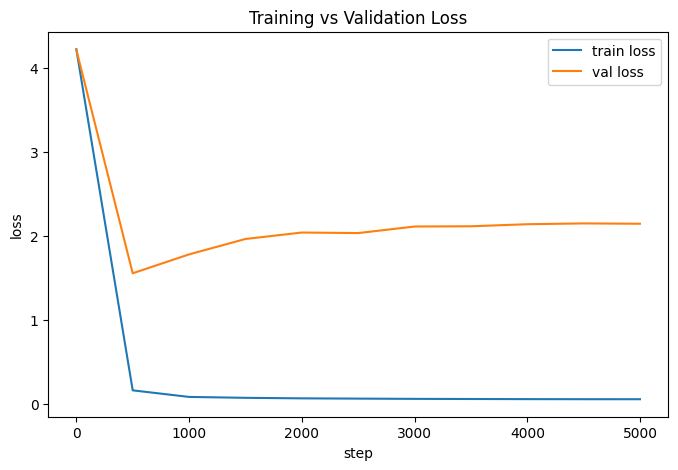

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(tracked_steps, train_losses, label='train loss')
plt.plot(tracked_steps, val_losses, label='val loss')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Training vs Validation Loss')
plt.legend()
import os
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/loss_curve.png')
plt.show()

## 16. Generate Text

Generate new text from the trained model, starting from an empty prompt. Uses temperature and top-k sampling (configured in `cfg`) for better quality than plain sampling.

In [20]:
start = torch.zeros((1, 1), dtype=torch.long, device=cfg.device)
generated = gpt_model.generate(start, max_new_tokens=300, temperature=cfg.temperature, top_k=cfg.top_k)
print(ds.tokenizer.decode(generated[0].tolist()))


A: You can reschedule the pickup from your return request page.

Q: Can I request faster refund processing?
A: Refund timelines are fixed, but we process them as quickly as possible.

Q: What if I receive an expired product?
A: Please report it immediately for a replacement or refund.

Q: Can I upda


## 17. Attention Visualization

Plots the attention weights from Layer 0, Head 0 for one validation sequence. Each row is a query position, each column a key position — brighter means stronger attention. You'll see it's lower-triangular (causal mask in action) — a position never attends to future positions.

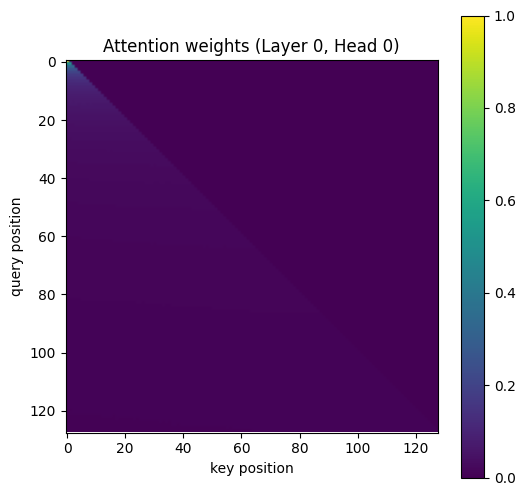

In [21]:
with torch.no_grad():
    xb, yb = ds.get_batch('val', 1, cfg.device)
    tok_emb = gpt_model.token_embedding_table(xb)
    pos_emb = gpt_model.position_embedding_table(torch.arange(xb.shape[1], device=cfg.device))
    x_in = tok_emb + pos_emb
    head0 = gpt_model.blocks[0].sa.heads[0]
    k = head0.key(x_in)
    q = head0.query(x_in)
    T = xb.shape[1]
    wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
    wei = wei.masked_fill(head0.tril[:T, :T] == 0, float('-inf'))
    wei = F.softmax(wei, dim=-1)[0].cpu().numpy()

plt.figure(figsize=(6, 6))
plt.imshow(wei, cmap='viridis')
plt.colorbar()
plt.title('Attention weights (Layer 0, Head 0)')
plt.xlabel('key position')
plt.ylabel('query position')
plt.savefig('assets/attention_heatmap.png')
plt.show()

## 18. Simple Frontend (Gradio)

A minimal web UI wrapping our `generate()` function — type a question, get a generated answer. Uses whatever model is currently loaded in `gpt_model` (either freshly trained or loaded from checkpoint).

In [22]:
!pip install -q gradio

In [23]:
import gradio as gr
import torch

def generate_response(question, max_tokens, temp, topk):
    # Guardrails
    if len(question.strip()) < 5:
        return "Please enter a more detailed question."

    if len(question.split()) < 2:
        return "I'm not sure I understand. Could you please clarify your question?"

    # Prompt formatting
    prompt = f"Q: {question}\nA:"
    prompt_ids = ds.tokenizer.encode(prompt)
    start = torch.tensor([prompt_ids], dtype=torch.long, device=cfg.device)

    # Generate response
    generated = gpt_model.generate(
        start,
        max_new_tokens=int(max_tokens),
        temperature=float(temp),
        top_k=int(topk)
    )

    # Decode output
    full_text = ds.tokenizer.decode(generated[0].tolist())
    answer = full_text[len(prompt):]

    # Stop at first newline (avoid extra Q&A spill)
    answer = answer.split('\n')[0].strip()

    return answer


# Gradio UI
demo = gr.Interface(
    fn=generate_response,
    inputs=[
        gr.Textbox(
            label="Your question",
            placeholder="e.g. How do I track my order?"
        ),
        gr.Slider(
            20, 200,
            value=100,
            step=10,
            label="Max tokens to generate"
        ),
        gr.Slider(
            0.1, 1.5,
            value=0.8,
            step=0.1,
            label="Temperature"
        ),
        gr.Slider(
            5, 100,
            value=40,
            step=5,
            label="Top-k"
        ),
    ],
    outputs=gr.Textbox(label="Generated answer"),
    title="Mini-GPT — Customer Support FAQ Demo",
    description=(
        "A decoder-only Transformer trained from scratch on FAQ data. "
        "Not guaranteed to be factually correct — this demonstrates the architecture, not a production support bot."
    )
)

# Launch app
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2a30a0f3767db44f9.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 19. Limitations

- The model is relatively small (~10M parameters)
- Trained on a limited dataset → prone to overfitting
- May generate incorrect or vague answers (hallucination)
- Not suitable for production without further scaling

## Future Improvements

- Increase dataset size and diversity
- Add retrieval (RAG) for grounded responses
- Fine-tune on real customer support logs
- Improve evaluation metrics and validation strategy

## 20. Conclusion

This project demonstrates:

- Building a GPT-style transformer from scratch
- Training a decoder-only language model
- Applying it to a real-world use case (customer support FAQ)
- Deploying an interactive interface using Gradio

Despite limitations due to model size and dataset constraints, the system successfully showcases the **end-to-end LLM pipeline** from data to deployment.

This serves as a strong foundation for further improvements such as retrieval integration and large-scale training.

## 21. Domain Limitation Demonstration

The model is trained only on customer support FAQ data.

When asked questions outside its domain (e.g., general knowledge), it still tries to generate an answer based on learned patterns.

Example:
- Input: "Who is the Prime Minister of India?"
- Output: "You will receive an order confirmation email..."

This demonstrates that:
- The model does not "know facts"
- It learns patterns from training data
- It lacks real-world grounding

This is a key limitation of small language models trained on narrow datasets.